### Correlation Analysis

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [28]:
outlets = pd.read_csv("Data/QSR_outlet_dataset_cleaned.csv", keep_default_na=False)
socioeconomic = pd.read_csv("Data/QSR_socioeconomic_dataset_cleaned.csv")

In [29]:
print("Outlet dataset shape:", outlets.shape)
print("Socioeconomic dataset shape:", socioeconomic.shape)

Outlet dataset shape: (2816, 17)
Socioeconomic dataset shape: (20, 9)


In [30]:
print("\nMissing values in outlet key columns:")
print(outlets[[
    "Region",
    "Customer_Rating",
    "Review_Count",
    "Price_Range_Cleaned",
    "Latitude",
    "Longitude"
]].isna().sum())


Missing values in outlet key columns:
Region                 0
Customer_Rating        0
Review_Count           0
Price_Range_Cleaned    0
Latitude               0
Longitude              0
dtype: int64


In [31]:
print("\nMissing values in socioeconomic dataset:")
print(socioeconomic.isna().sum())


Missing values in socioeconomic dataset:
Region                          0
Province_Count                  0
Region_Area                     0
Population                      0
Population Density              0
Disposable Income per capita    0
Total Tourism Flow              0
Foreign Tourism Flow            0
Median Income                   0
dtype: int64


In [32]:
regional_qsr = outlets.groupby("Region").agg(
    Outlet_Count=("Outlet ID", "count"),
    Average_Rating=("Customer_Rating", "mean"),
    Average_Review_Count=("Review_Count", "mean")
).reset_index()

regional_analysis = regional_qsr.merge(
    socioeconomic,
    on="Region",
    how="left"
)

regional_analysis["Outlets_per_100k_people"] = (
    regional_analysis["Outlet_Count"] / regional_analysis["Population"] * 100000
)

regional_analysis.head()

,Region,Outlet_Count,Average_Rating,Average_Review_Count,Province_Count,Region_Area,Population,Population Density,Disposable Income per capita,Total Tourism Flow,Foreign Tourism Flow,Median Income,Outlets_per_100k_people
0,Abruzzo,56,3.941071,1351.732143,4,10831.84,1267222,117.0,19768,6804820.0,978924.0,24767,4.419115
1,Basilicata,4,3.575000,1387.250000,2,10073.32,525281,52.1,17336,2537324.0,428180.0,24984,0.761497
2,Calabria,34,4.188235,1443.411765,5,15221.90,1827571,120.1,16173,8100594.0,1486391.0,22225,1.860393
3,Campania,125,3.810400,1817.952000,5,13670.95,5568703,407.3,16445,20695842.0,10601880.0,23751,2.244688
4,Emilia-Romagna,244,3.807377,3114.061475,9,22452.78,4477009,199.4,26072,39176137.0,11087454.0,35682,5.450067


In [33]:
correlation_variables = regional_analysis[[
    "Outlet_Count",
    "Outlets_per_100k_people",
    "Average_Rating",
    "Average_Review_Count",
    "Population",
    "Population Density",
    "Disposable Income per capita",
    "Total Tourism Flow",
    "Foreign Tourism Flow",
    "Median Income"
]]

correlation_matrix = correlation_variables.corr()

correlation_matrix

,Outlet_Count,Outlets_per_100k_people,Average_Rating,Average_Review_Count,Population,Population Density,Disposable Income per capita,Total Tourism Flow,Foreign Tourism Flow,Median Income
Outlet_Count,1.000000,0.785377,-0.082434,0.100752,0.896276,0.732135,0.451389,0.540532,0.532550,0.254663
Outlets_per_100k_people,0.785377,1.000000,-0.103712,0.243506,0.585079,0.517307,0.727074,0.506750,0.482814,0.519479
Average_Rating,-0.082434,-0.103712,1.000000,-0.272560,-0.026868,-0.041780,-0.426481,-0.224279,-0.228113,-0.440172
Average_Review_Count,0.100752,0.243506,-0.272560,1.000000,0.154052,0.254397,0.545783,0.486116,0.307278,0.601623
Population,0.896276,0.585079,-0.026868,0.154052,1.000000,0.852627,0.197487,0.563133,0.530306,0.071032
Population Density,0.732135,0.517307,-0.041780,0.254397,0.852627,1.000000,0.167786,0.471101,0.457362,0.005360
Disposable Income per capita,0.451389,0.727074,-0.426481,0.545783,0.197487,0.167786,1.000000,0.552401,0.519507,0.869032
Total Tourism Flow,0.540532,0.506750,-0.224279,0.486116,0.563133,0.471101,0.552401,1.000000,0.969461,0.519611
Foreign Tourism Flow,0.532550,0.482814,-0.228113,0.307278,0.530306,0.457362,0.519507,0.969461,1.000000,0.453348
Median Income,0.254663,0.519479,-0.440172,0.601623,0.071032,0.005360,0.869032,0.519611,0.453348,1.000000


The correlation matrix shows that QSR outlet presence is strongly correlated with regional population with a positive number of about 0.896, meaning regions with larger populations tend to have more QSR outlets. 

Same is true for Population Density = 0.73, suggesting that more crowded regions may attract more QSR locations.

Outlets_per_100k_people is most strongly correlated with Disposable Income per capita = 0.727 and Median Income = 0.519. So, richer and regions may have a higher concentration of QSR outlets relative to population.

Average_Rating does not show a strong positive relationship with outlet count or population. with values of -0.082 and -0.03. suggesting that the number of outlets in a region does not strongly explain average customer ratings.

The matrix also shows strong correlations between some explanatory variables, like with Total Tourism Flow and Foreign Tourism Flow, and between Disposable Income per capita and Median Income.So this is a sign of multicollinearity.

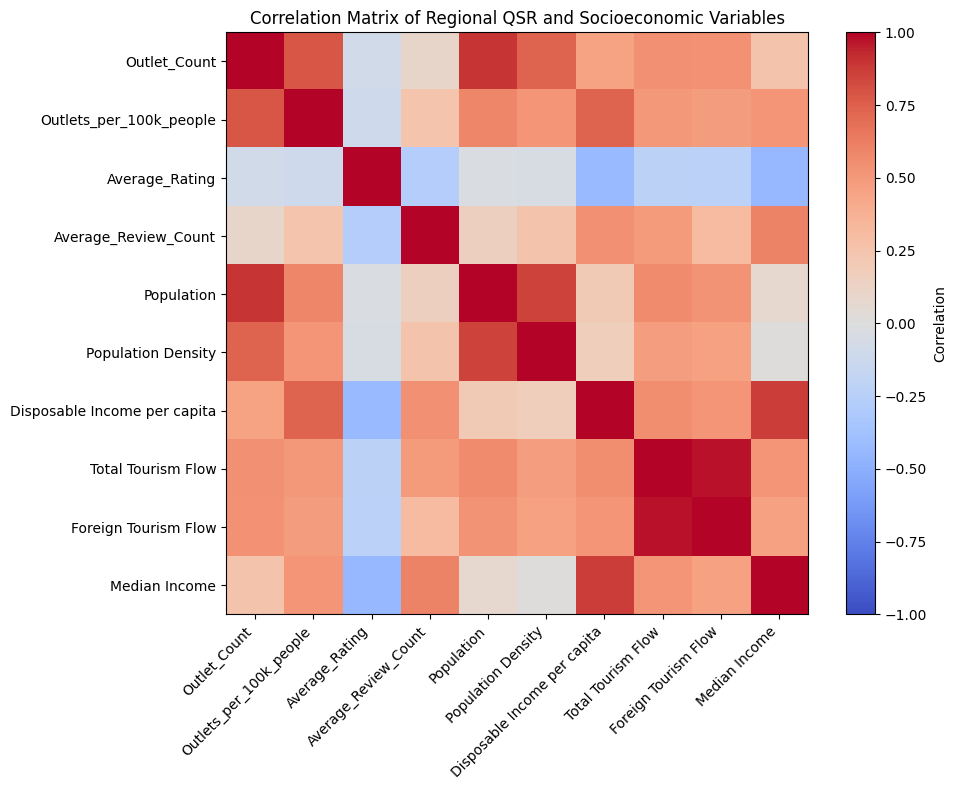

In [34]:
plt.figure(figsize=(10, 8))

plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Correlation Matrix of Regional QSR and Socioeconomic Variables")
plt.tight_layout()
plt.show()

This heatmap is only for visual representation I thought maybe it can help me with the thesis or report

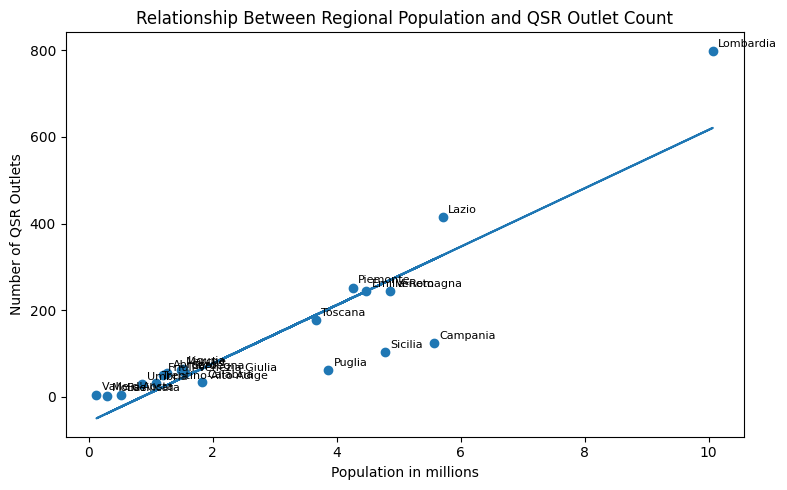

In [35]:
plt.figure(figsize=(8, 5))

x = regional_analysis["Population"] / 1000000
y = regional_analysis["Outlet_Count"]

plt.scatter(x, y)

m, b = np.polyfit(x, y, 1)
plt.plot(x, m * x + b)

for i, row in regional_analysis.iterrows():
    plt.annotate(
        row["Region"],
        (row["Population"] / 1000000, row["Outlet_Count"]),
        fontsize=8,
        xytext=(4, 3),
        textcoords="offset points"
    )

plt.title("Relationship Between Regional Population and QSR Outlet Count")
plt.xlabel("Population in millions")
plt.ylabel("Number of QSR Outlets")
plt.tight_layout()
plt.show()

This is again just the visual representation of outlet count and population showing clear positive relationship between them.

In [36]:
main_correlation_results = correlation_matrix[[
    "Outlet_Count",
    "Outlets_per_100k_people",
    "Average_Rating"
]].drop([
    "Outlet_Count",
    "Outlets_per_100k_people",
    "Average_Rating",
    "Average_Review_Count"
])

main_correlation_results.round(3)

,Outlet_Count,Outlets_per_100k_people,Average_Rating
Population,0.896,0.585,-0.027
Population Density,0.732,0.517,-0.042
Disposable Income per capita,0.451,0.727,-0.426
Total Tourism Flow,0.541,0.507,-0.224
Foreign Tourism Flow,0.533,0.483,-0.228
Median Income,0.255,0.519,-0.440


This table focuses on the main findings

In [37]:
spearman_correlation_matrix = correlation_variables.corr(method="spearman")

spearman_main_results = spearman_correlation_matrix[[
    "Outlet_Count",
    "Outlets_per_100k_people",
    "Average_Rating"
]].drop([
    "Outlet_Count",
    "Outlets_per_100k_people",
    "Average_Rating",
    "Average_Review_Count"
])

spearman_main_results.round(3)

,Outlet_Count,Outlets_per_100k_people,Average_Rating
Population,0.910,0.498,0.062
Population Density,0.878,0.540,-0.026
Disposable Income per capita,0.305,0.686,-0.562
Total Tourism Flow,0.744,0.498,-0.212
Foreign Tourism Flow,0.733,0.559,-0.287
Median Income,0.129,0.493,-0.459


I used spearman correlation here to have a better idea as the pearsons correlation measures straight line relationships and is strongly influenced by very large values like lombardia and lazio.

Here we see that the Spearman results are mostly consistent with the Pearson results. Outlet_Count still has a very strong positive relationship with Population = 0.910 and Population Density = 0.878 which confirms that the relationship between regional size, density, and QSR outlet count is not only driven by the exact numeric values, but also by the ranking of regions.

Again, Outlets_per_100k_people remains most strongly related to Disposable Income per capita = 0.686, which supports the earlier finding that income may matter more when outlet count is adjusted for population.